In [1]:
%load_ext autoreload
%autoreload 2
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS, SklearnUNFISWrapper
from model.GIFT import GIFT, SklearnGIFTWrapper, MamdaniGIFT
from model.anfis import ANFIS, SklearnAnfisWrapper
from model.griffin import GRIFFIN, SklearnGRIFFINrapper
from model.giftshift import GIFTSHIFT, SklearnGIFTSHIFTWrapper
from model.giftshifter import GIFTSHIFTER, SklearnGIFTSHIFTERWrapper
from model.admtsk import ADMTSK, SklearnADMTSKWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from tests.evaluate import Evaluator, TopKEvaluator
from utils.plot_style import apply_plot_style

apply_plot_style()

# TODO: del "giftshiftentropy"


In [2]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0
noise_evaluate = True

# Repeated training: run n_runs times, then report mean ± std over the top_k best runs
n_runs = 1000
top_k = 30
# ranking_metric: "test_acc", "test_auc", or "both" (acc/auc each ranked by its own metric)
ranking_metric = "both"

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [3]:
# dataset

from tests.tabular_small import (
    Cryotheraphy, Haberman, Heart, Glass, SegmentaitionUCI, Wine, Thyroid,
    Immunotherapy, Iris, BreastCancer, PimaDiabetes, CarEvaluation, Autism,
    Digits, DNA, MFeat, Parkinson, SyntheticGaussian, PimaDiabetesCase2,
    DigitsUCI as Digits_UCI, BCW,
)
from tests.tabular_large import AdultIncome, BankMarketing, Smoke
from tests.bio_medical import Diabetes, Colon, Leukemia, SRBCT, Madelon, ORL, Isolet
from tests.image import MNIST, FashionMNIST
from tests.uci_thresholded import (
    EnergyEfficiencyHeating, EnergyEfficiencyCooling, Airfoil, Concrete,
    ConcreteMulticlass, CCPP,
)
from tests.inequality import (
    LinearThreshold, ExponentialGrowth, LogisticGrowth, DampedOscillator, PDE,
)
from torch.utils.data import DataLoader

# Split strategy — pick ONE:
#   "train_test"      -> holdout train + test (default 70/30, or set holdout_ratios)
#   "train_val_test"  -> holdout train + validation + test (3-tuple holdout_ratios)
#   "kfold"           -> stratified k-fold CV (set n_folds and fold_split_ratios)
split_strategy = "kfold"

holdout_ratios = (0.7, 0.3)           # train/test, or train/val/test when using train_val_test
n_folds = 10
fold_split_ratios = (0.9, 0.1)        # train/test per fold; test fraction must equal 1/n_folds

experiment_kwargs = dict(session_id=random_state)
if split_strategy == "train_test":
    if holdout_ratios != (0.7, 0.3):
        experiment_kwargs["split_ratios"] = holdout_ratios
elif split_strategy == "train_val_test":
    if len(holdout_ratios) != 3:
        raise ValueError("train_val_test requires a 3-tuple holdout_ratios (train, val, test)")
    experiment_kwargs["split_ratios"] = holdout_ratios
elif split_strategy == "kfold":
    experiment_kwargs["split_mode"] = "kfold"
    experiment_kwargs["n_folds"] = n_folds
    experiment_kwargs["split_ratios"] = fold_split_ratios
else:
    raise ValueError(
        f"split_strategy must be 'train_test', 'train_val_test', or 'kfold', got {split_strategy!r}"
    )

experiment = MFeat(**experiment_kwargs)

print(experiment.split_description())

train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

if experiment.has_validation_split():
    val_dataset = experiment.val_dataset(device)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
else:
    val_dataset = val_loader = None

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
regression = False

fresh 70/30 redrawn each run (PyCaret session_id)


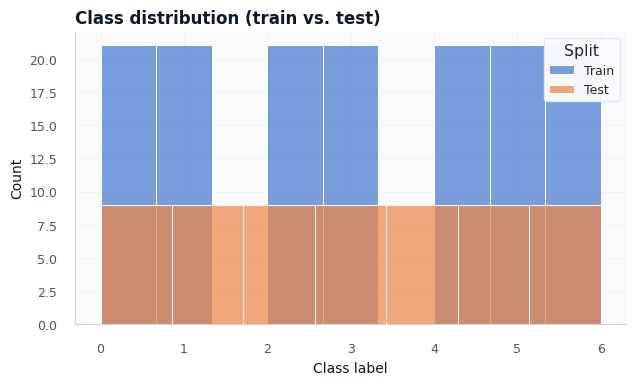

False

In [4]:
from utils.plot_style import CLASS_SCATTER, apply_plot_style, save_figure, style_axes

y_train = experiment.train_numpy()[1]
y_test = experiment.test_numpy()[1]

fig, ax = plt.subplots(figsize=(6.5, 4), facecolor="white")
style_axes(ax)
palette = sns.color_palette("muted", 2)
sns.histplot(
    y_train, ax=ax, color=palette[0], alpha=0.72,
    label="Train", kde=False, edgecolor="white", linewidth=0.7,
    stat="count",
)
sns.histplot(
    y_test, ax=ax, color=palette[1], alpha=0.72,
    label="Test", kde=False, edgecolor="white", linewidth=0.7,
    stat="count",
)
ax.set_xlabel("Class label")
ax.set_ylabel("Count")
ax.set_title("Class distribution (train vs. test)", loc="left", fontweight="600")
ax.legend(title="Split", frameon=True)
fig.tight_layout()
save_figure(fig, "figures/class_distribution")
plt.show()

binary = len(np.unique(y_train)) == 2
binary


🔇 NOISE IS DISABLED - Clean data evaluation only


Noise levels:   0%|          | 0/1 [00:00<?, ?it/s]


Testing: CLEAN DATA (σ = 0)

Training GIFTSHIFTER...
  Run 1/1000... Acc=0.8889, LingRich=0.8570, RelaxRate=0.4717
  Run 2/1000... Acc=0.9206, LingRich=0.6806, RelaxRate=0.4845
  Run 3/1000... Acc=0.8571, LingRich=0.8629, RelaxRate=0.4988
  Run 4/1000... Acc=0.8730, LingRich=0.7659, RelaxRate=0.5306
  Run 5/1000... Acc=0.8254, LingRich=0.6806, RelaxRate=0.4725
  Run 6/1000... Acc=0.9048, LingRich=0.6237, RelaxRate=0.4844
  Run 7/1000... Acc=0.9048, LingRich=0.6918, RelaxRate=0.4750
  Run 8/1000... Acc=0.9048, LingRich=0.6918, RelaxRate=0.4807
  Run 9/1000... Acc=0.8889, LingRich=0.6806, RelaxRate=0.4828
  Run 10/1000... Acc=0.9048, LingRich=0.6918, RelaxRate=0.4833
  Run 11/1000... Acc=0.8889, LingRich=0.8393, RelaxRate=0.4914
  Run 12/1000... Acc=0.9048, LingRich=0.8570, RelaxRate=0.4870
  Run 13/1000... Acc=0.8730, LingRich=0.8393, RelaxRate=0.4866
  Run 14/1000... Acc=0.8571, LingRich=0.6237, RelaxRate=0.5042
  Run 15/1000... Acc=0.9524, LingRich=0.6806, RelaxRate=0.4685
  Run 16/1

Noise levels: 100%|██████████| 1/1 [35:36<00:00, 2136.95s/it]

Acc=0.9365, LingRich=0.6918, RelaxRate=0.4792

MODEL EVALUATION REPORT
Dataset: SegmentaitionUCI
Noise Enabled: False
Total runs per configuration: 1000 (mean ± std over top 30 runs: acc ranked by test_acc, auc ranked by test_auc)
Train/validation/test split: fresh 70/30 redrawn each run (PyCaret session_id)

📊 PERFORMANCE SUMMARY:
-------------------------------------------------------------------------------------------------------------------------------------------------
Model           Noise σ    Test Acc ± Std (top-30 runs, by acc) Test AUC ± Std (top-30 runs, by auc) Ling. Richness ± Std (top-30 runs, by acc) Relax. Rate ± Std (top-30 runs, by acc)
-------------------------------------------------------------------------------------------------------------------------------------------------
GIFTSHIFTER     Clean      0.9661 ± 0.0128    0.9989 ± 0.0005    0.7328 ± 0.0760            0.4979 ± 0.0108         

📖 LINGUISTIC RICHNESS (clean data, higher = more relational diversity pe

Saved bubble chart: figures/model_landscape.png, figures/model_landscape.pdf, figures/model_landscape.svg


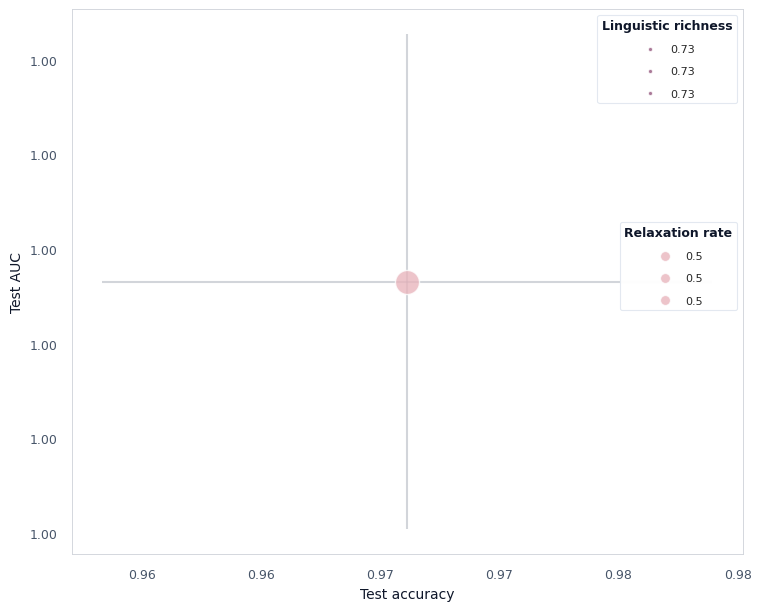

In [7]:
# Import necessary modules
import torch
import numpy as np
from tests.evaluate import Evaluator

# Configure device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Define model configurations
model_configs = {
    'giftshifter': {
        'model_class': GIFTSHIFTER,
        'wrapper_class': SklearnGIFTSHIFTERWrapper,
        'params': {
            'rules': 1,
            'drop_out_p': 0.3,
        }
    }
} 

'''
'Litanfis': {
        'model_class': LitAnfis,
        'wrapper_class': SklearnLitAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 

'GIFTSHIFTENTROPY': {
        'model_class': GIFTSHIFTENTROPY,
        'wrapper_class': SklearnGIFTSHIFTENTROPYWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
            'entropy_coef': 0.0005
        }
    }


'GIFTSHIFT': {
        'model_class': GIFTSHIFT,
        'wrapper_class': SklearnGIFTSHIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

'giftshifter': {
        'model_class': GIFTSHIFTER,
        'wrapper_class': SklearnGIFTSHIFTERWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 
    
'Anfis': {
        'model_class': ANFIS,
        'wrapper_class': SklearnAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    },

'Unfis': {
        'model_class': UNFIS,
        'wrapper_class': SklearnAnfisWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    },

'Griffin': {
        'model_class': GRIFFIN,
        'wrapper_class': SklearnGRIFFINrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }

'''


# Define learning parameters
learning_params = {
    'batch_size': 32,
    'lr': 0.01,
    'max_lr': 0.01,
    'epochs': 100,
    'alpha': 1.0,
    'min_alpha': 0.0
}

evaluator = Evaluator(
    experiment=experiment,
    model_configs=model_configs,
    learning_params=learning_params,
    device=device,
    binary=binary,
    noise_levels=[0.0],
    random_state=random_state,
    use_noise=False,
    use_early_stopping=False,
    noise_type="gaussian",
)

# Run evaluation (10 folds for k-fold CV)
results_df = evaluator.evaluate(verbose=True)

# Print detailed report (test acc ± std and test auc ± std across folds)
evaluator.print_detailed_report()

summary_df = evaluator.get_summary_statistics()
summary_df[["model", "test_acc_mean", "test_acc_std", "test_auc_mean", "test_auc_std"]]

# Model landscape bubble (clean data): acc vs AUC, size = linguistic richness
evaluator.plot_model_landscape(
    save_path="figures/model_landscape",
    interactive=False,
)

# Line / bar charts when noise sweep is enabled
if evaluator.use_noise:
    evaluator.plot_robustness_curves(save_path="figures/robustness_curves")
    evaluator.plot_relative_performance(save_path="figures/relative_performance")

In [ ]:
# Paper-faithful ADMTSK configuration (paste into model_configs / learning_params).
# Requires fold-local MinMax to [0, 1]: e.g. experiment(..., normalize=True, normalize_method='minmax').
# Do not use TopKEvaluator for paper reporting — use Evaluator with k-fold and mean±std over all folds.

import math
import numpy as np
from model.admtsk import ADMTSK, SklearnADMTSKWrapper

n_classes = len(np.unique(y_train))  # or evaluator.n_classes

admtsk_config = {
    'ADMTSK': {
        'model_class': ADMTSK,
        'wrapper_class': SklearnADMTSKWrapper,
        'params': {
            'rules': 3,
            'out_features': n_classes,
            'binary': binary,
            'K': 10.0,
            'membership_lower_bound': 1 / np.e,
            'feature_chunk_size': 4096,
            'validate_input_range': True,
            'paper_mode': True,
        },
        'training': {
            'loss_mode': 'paper_mse',
            'uses_reconstruction': False,
            'scheduler': 'none',
        },
    }
}

# Paper training defaults (batch size = round(batch_ratio * N_train)):
#   epochs=50, lr in {0.01, 0.001, 0.0001}, batch_ratio in {0.1, 0.2}
# Example learning_params for a single paper setting:
admtsk_learning_params = {
    'batch_size': max(1, round(0.2 * len(y_train))),  # replace with fold train size
    'lr': 0.001,
    'max_lr': 0.001,  # unused when scheduler='none'
    'epochs': 50,
    'alpha': 0.0,
    'min_alpha': 0.0,
}


## Interpretability: rule regions & decision boundary (Haberman)

To show that the learned fuzzy rules genuinely partition the input space, we
project the Haberman data onto its two main features — **positive axillary
nodes vs age** — while holding every other feature fixed at its mean value.
A dense grid over these two features is fed to the trained model and each grid
point is coloured by (a) the **dominant rule** that fires there and (b) the
**predicted class**. The contiguous rule-coloured regions are visual proof that
the rules carve the space into interpretable areas, and the decision boundary
shows how those regions combine into a prediction.


Features -> x: num_imputer__positive_auxillary_nodes (idx 2), y: num_imputer__age (idx 0)
Haberman test accuracy: 0.7065
Saved interpretability figure: figures/haberman_interpretability.png, figures/haberman_interpretability.pdf


(<Figure size 1400x650 with 2 Axes>,
 array([<Axes: title={'left': '(A) Dominant rule regions'}, xlabel='Positive Auxillary Nodes', ylabel='Age'>,
        <Axes: title={'left': '(B) Predicted class regions'}, xlabel='Positive Auxillary Nodes', ylabel='Age'>],
       dtype=object))

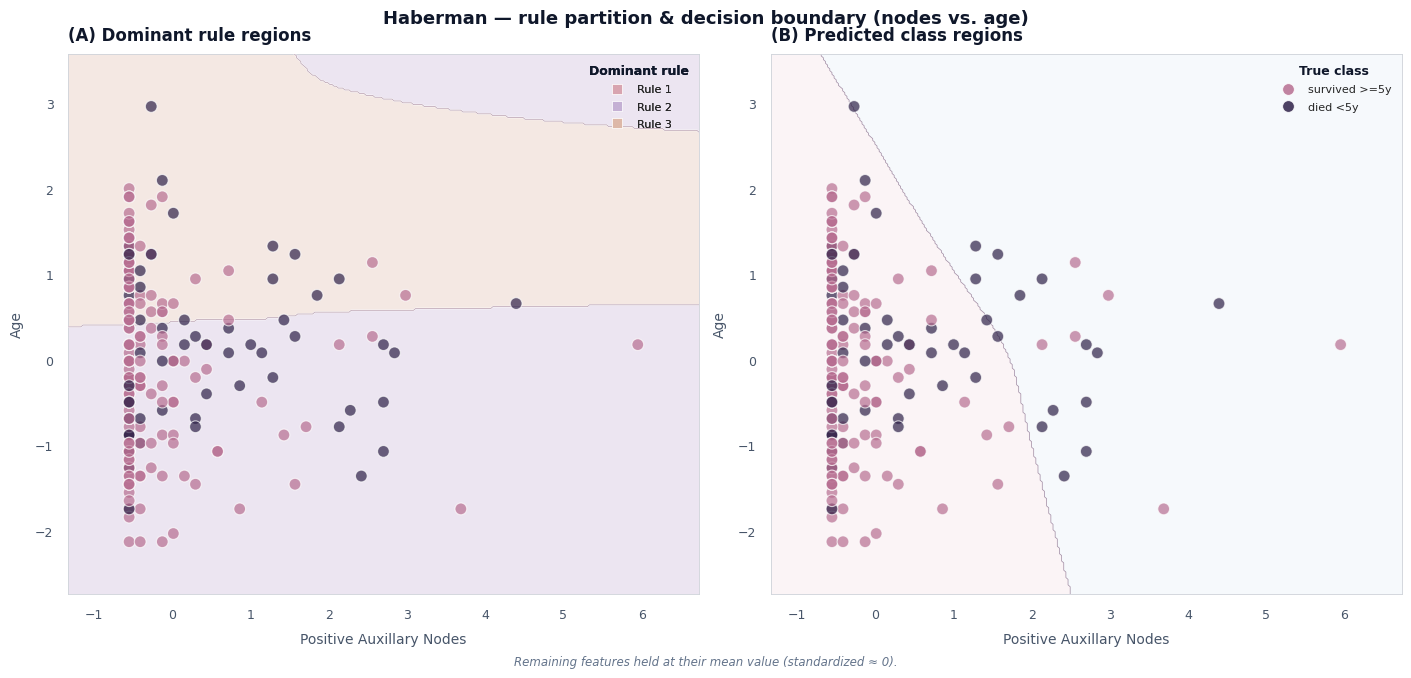

In [ ]:
# interpretability-haberman

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

from tests.tabular_small import Haberman
from model.giftshifter import GIFTSHIFTER
from utils.decision_boundary import plot_interpretability_2d
from utils.plot_style import plot_dense_bubble
from utils.verbalize_rules import clean_feature_name
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Haberman (data is standardized -> "mean value" of held-fixed features is ~0)
hab = Haberman(session_id=random_state)
X_train, y_train = hab.train_numpy()
X_test, y_test = hab.test_numpy()
feature_names = list(hab.clf.X_train_transformed.columns)
hab_binary = len(np.unique(y_train)) == 2


def _find_feature(names, *keywords, default=0):
    """Index of the first feature whose (lowercased) name contains all keywords."""
    for i, name in enumerate(names):
        low = name.lower()
        if all(k in low for k in keywords):
            return i
    return default


# The two "main" features requested: positive axillary nodes vs age.
idx_nodes = _find_feature(feature_names, "nod", default=2)
idx_age = _find_feature(feature_names, "age", default=0)
print(f"Features -> x: {feature_names[idx_nodes]} (idx {idx_nodes}), "
      f"y: {feature_names[idx_age]} (idx {idx_age})")

# Train a compact GIFTSHIFTER so the rule partition stays readable.
hab_rules = 3
model = GIFTSHIFTER(
    in_features=X_train.shape[1],
    rules=hab_rules,
    out_features=1 if hab_binary else len(np.unique(y_train)),
    binary=hab_binary,
    drop_out_p=0.3,
    dtype=torch.float32,
).to(device)

y_tensor = torch.tensor(y_train, dtype=torch.float32 if hab_binary else torch.long)
loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), y_tensor),
    batch_size=32, shuffle=True,
)

n_epochs = 150
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(loader), epochs=n_epochs)
l1 = nn.L1Loss()
task_loss = nn.BCEWithLogitsLoss() if hab_binary else nn.CrossEntropyLoss()

model.train()
for epoch in range(n_epochs):
    for bx, by in loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out, recon, _ = model(bx)
        if hab_binary:
            loss = task_loss(out.squeeze(), by.squeeze()) + l1(recon, bx)
        else:
            loss = task_loss(out, by.long()) + l1(recon, bx)
        loss.backward()
        optimizer.step()
        try:
            scheduler.step()
        except ValueError:
            pass
model.eval()

with torch.no_grad():
    logits = model(torch.tensor(X_test, dtype=torch.float32, device=device))[0]
    if hab_binary:
        pred = (torch.sigmoid(logits).squeeze() > 0.5).long().cpu().numpy()
    else:
        pred = logits.argmax(1).cpu().numpy()
print(f"Haberman test accuracy: {(pred == y_test).mean():.4f}")

class_names = [r"Survived $\geq$ 5 years", "Died within 5 years"]

idx_year = _find_feature(feature_names, "year", default=1)
bubble_df = pd.DataFrame({
    "nodes": X_train[:, idx_nodes],
    "age": X_train[:, idx_age],
    "year": X_train[:, idx_year],
    "survival": y_train.astype(float),
})

# Caption belongs in LaTeX; axes remain in standardized model space.
plot_interpretability_2d(
    model, X_train, y_train,
    feature_x=idx_nodes, feature_y=idx_age,
    feature_names=feature_names, class_names=class_names,
    resolution=300,
    axis_scale="standardized",
    save_path="artifacts/figures/HabermanBoundary/HabermanBoundary",
)


### Verbalised rules (text & LaTeX)

The same trained model can be read out rule-by-rule: for each feature antecedent we
report whether it uses the **identity** stream (`is` / `is not` centre *A*) or the
**order** stream (`is at least` / `is at most` *A*), or is **relaxed** when
`ρ > 0.8`. Features are joined with AND within each rule.

In [ ]:
# verbalize-rules-haberman

from IPython.display import Latex, Markdown, display
from utils.verbalize_rules import verbalize_rules

latex_table, plain_rules = verbalize_rules(
    model,
    feature_names=feature_names,
    class_names=class_names,
    threshold_w=0.65,
)

print("Plain-text rules:")
print(plain_rules)
print()

display(Markdown("**LaTeX rule table (one row per rule):**"))
display(Latex(latex_table))

Plain-text rules:
Rule 1: IF Age (relaxed — don't care) [m=1.58, σ=0.55] AND Operation Year is A(1,2) [m=1.34, σ=0.54] AND Positive Auxillary Nodes is at least A(1,3) [m=0.45, σ=0.56] THEN survived >=5y
Rule 2: IF Age is not A(2,1) [m=1.38, σ=1.40] AND Operation Year is at least A(2,2) [m=-0.02, σ=0.33] AND Positive Auxillary Nodes is at least A(2,3) [m=0.82, σ=0.57] THEN survived >=5y
Rule 3: IF Age is at least A(3,1) [m=0.66, σ=0.48] AND Operation Year is not A(3,2) [m=0.68, σ=0.62] AND Positive Auxillary Nodes is at least A(3,3) [m=1.08, σ=0.34] THEN survived >=5y



**LaTeX rule table (one row per rule):**

<IPython.core.display.Latex object>

### Relaxation heatmap (rules x features)

The consequent relaxation coefficient `r_{i,j}` has no 2D limitation, so we can
show all features at once as a `rules x features` matrix. **Dark cells** mean the
feature is fully **active** in that rule (`r ~ 0`), while **light cells** mean it
is **relaxed / ignored** (`r ~ 1`). This exposes, per rule, exactly which inputs
the model actually relies on.


Saved relaxation heatmap: figures/haberman_relaxation.png, figures/haberman_relaxation.pdf


<Axes: title={'left': 'Haberman — consequent relaxation r (dark = active, light = ignored)'}, xlabel='Feature', ylabel='Rule'>

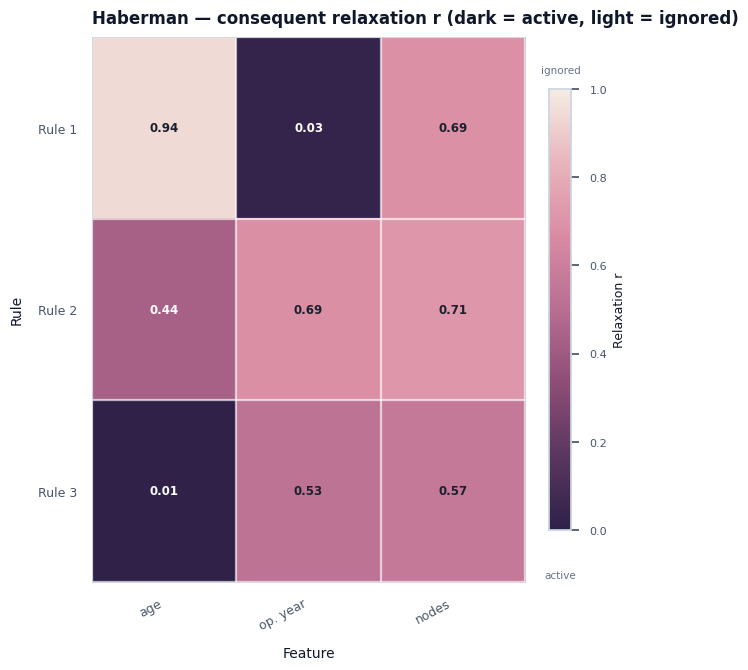

In [ ]:
# relaxation-heatmap-haberman

from utils.relaxation import plot_relaxation_heatmap

plot_relaxation_heatmap(
    model,
    feature_names=feature_names,
    rule_names=[f"Rule {i + 1}" for i in range(model.rules_count)],
    save_path="artifacts/figures/HabermanRelaxation/HabermanRelaxation",
)
